In [9]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score,
    average_precision_score,
    PrecisionRecallDisplay,
)

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import joblib

sns.set(style="whitegrid")

In [10]:
fraud_df = pd.read_csv(r"C:\Users\bless\OneDrive\Desktop\week-8\fraud-detection-project\data\Fraud_Data.csv")
credit_df = pd.read_csv(r"C:\Users\bless\OneDrive\Desktop\week-8\fraud-detection-project\data\creditcard.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [11]:
drop_cols = ['signup_time', 'purchase_time', 'device_id', 'ip_address', 'browser', 'source', 'sex']
fraud_df = fraud_df.drop(columns=[col for col in drop_cols if col in fraud_df.columns])


In [12]:
def prepare_data(df, target_column, scale=True):
    X = df.drop(columns=[target_column])
    y = df[target_column]

    X = X.select_dtypes(include=[np.number])

    scaler = None
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    return train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42), scaler


In [13]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"📌 {name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("PR AUC Score:", average_precision_score(y_test, y_proba))

    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f'Precision-Recall Curve: {name}')
    plt.show()


In [14]:
(X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud), scaler_fraud = prepare_data(fraud_df, 'class')

📌 Logistic Regression (Fraud Data)
Confusion Matrix:
 [[14929 12420]
 [14535 12901]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.55      0.53     27349
           1       0.51      0.47      0.49     27436

    accuracy                           0.51     54785
   macro avg       0.51      0.51      0.51     54785
weighted avg       0.51      0.51      0.51     54785

ROC AUC Score: 0.5085528743332466
F1 Score: 0.48907254013685386
PR AUC Score: 0.5049054939934785


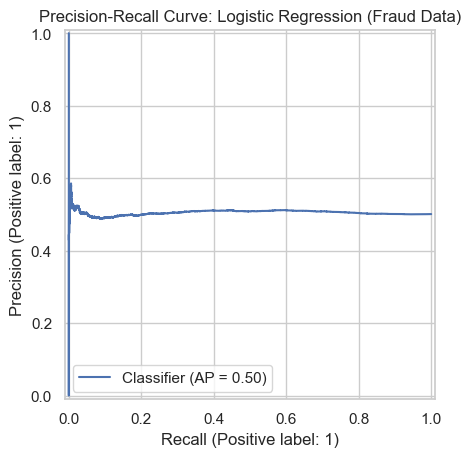

In [15]:
lr_fraud = LogisticRegression(max_iter=1000)
lr_fraud.fit(X_train_fraud, y_train_fraud)
evaluate_model(lr_fraud, X_test_fraud, y_test_fraud, "Logistic Regression (Fraud Data)")

c:\Users\bless\OneDrive\Desktop\week-8\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:57:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📌 XGBoost (Fraud Data)
Confusion Matrix:
 [[24820  2529]
 [ 9177 18259]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81     27349
           1       0.88      0.67      0.76     27436

    accuracy                           0.79     54785
   macro avg       0.80      0.79      0.78     54785
weighted avg       0.80      0.79      0.78     54785

ROC AUC Score: 0.8696326324757057
F1 Score: 0.757257796947578
PR AUC Score: 0.8957055582256742


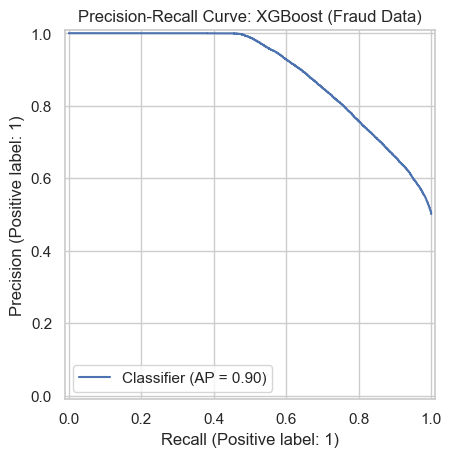

In [16]:
xgb_fraud = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_fraud.fit(X_train_fraud, y_train_fraud)
evaluate_model(xgb_fraud, X_test_fraud, y_test_fraud, "XGBoost (Fraud Data)")

In [17]:
(X_train_credit, X_test_credit, y_train_credit, y_test_credit), scaler_credit = prepare_data(credit_df, 'Class')

📌 Logistic Regression (Credit Card Data)
Confusion Matrix:
 [[55361  1389]
 [ 4289 52687]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     56750
           1       0.97      0.92      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726

ROC AUC Score: 0.989972291757129
F1 Score: 0.9488707992652091
PR AUC Score: 0.9911711409388005


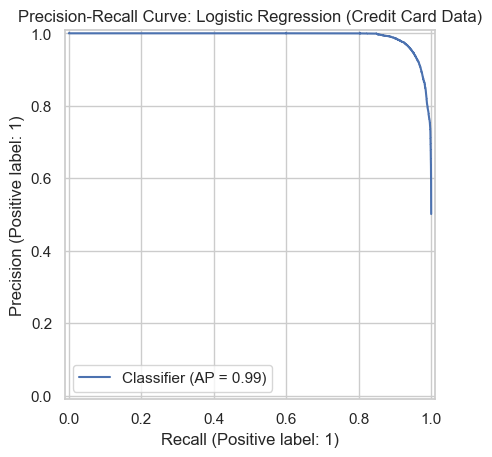

In [18]:
lr_credit = LogisticRegression(max_iter=1000)
lr_credit.fit(X_train_credit, y_train_credit)
evaluate_model(lr_credit, X_test_credit, y_test_credit, "Logistic Regression (Credit Card Data)")

c:\Users\bless\OneDrive\Desktop\week-8\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:58:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📌 XGBoost (Credit Card Data)
Confusion Matrix:
 [[56719    31]
 [    0 56976]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC AUC Score: 0.999994441434186
F1 Score: 0.9997280296184519
PR AUC Score: 0.999993951716072


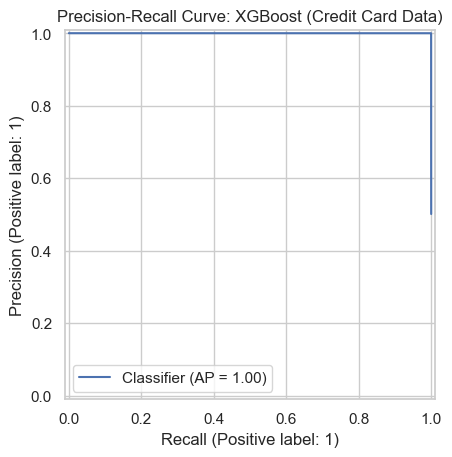

In [19]:
xgb_credit = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_credit.fit(X_train_credit, y_train_credit)
evaluate_model(xgb_credit, X_test_credit, y_test_credit, "XGBoost (Credit Card Data)")

In [21]:
joblib.dump(lr_fraud, "../models/saved_models/fraud_logreg.pkl")
joblib.dump(xgb_fraud, "../models/saved_models/fraud_xgboost.pkl")
joblib.dump(scaler_fraud, "../models/saved_models/fraud_scaler.pkl")

['../models/saved_models/fraud_scaler.pkl']

In [22]:
joblib.dump(lr_credit, "../models/saved_models/credit_logreg.pkl")
joblib.dump(xgb_credit, "../models/saved_models/credit_xgboost.pkl")
joblib.dump(scaler_credit, "../models/saved_models/credit_scaler.pkl")

['../models/saved_models/credit_scaler.pkl']